In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("HW_3_classes_and_simulation.ipynb")

# Homework 3: Simulating a half car

Slides for the homework: https://docs.google.com/presentation/d/1y6dZiGuSJBfha_5wPd5DEESuZWS8VUTdkc9zYLLOIoI/edit?usp=sharing

In the labs, you learned how to draw, animate, and simulate a quarter car as it travels down a road. You learned about state space models, and how computer simulations operate over discrete steps with a specific time delta, `dt`, and how the choice of `dt` is important for making sure your simulation is accurate without being too slow.

In this homework, you will combine two quarter cars to form a _half car_, and simulate it driving down a road. You will experiment with different half car parameters and roads.

Refer to the assignment slides for a diagram of a half car.

While the quarter car state space model solved for $y_u$ and $y_s$, the half car system has four variables we need to solve for:

* $y_s$: y position of the sprung mass (body), which is now attached to a front and back suspension
* $\theta$: angle of the sprung mass, since the car body will tilt as it moves
* $y_{uf}$: y position of the front unsprung mass (front wheel)
* $y_{ub}$: y position of the back unsprung mass (back wheel)

And it now has two input variables:

* $y_{rf}$: y position of the road under the front tire.
* $y_{rb}$: y position of the road under the back tire.

Both of those input variables can be derived from the same road, but at different `x` offsets.

The system shares the same "fixed" properties of the quarter car, but they are doubled as we now have a front and back of a car:

* $k_{sf}$, $k_{sb}$: Spring constant for the front and back suspensions' spring.
* $c_{sf}$, $c_{sb}$: Damping constant of front and back suspensions' damper.
* $k_{tf}$, $k_{tb}$: Spring constant for front and back tires.

The system also has two new fixed properties related to the shared sprung mass:

* $a_f$, $a_b$: Distance between center of gravity of the car and the front and back of the car, respectively.

In [2]:
# Imports
import numpy as np
from scipy.stats import gamma
from scipy.signal import StateSpace, lsim
import matplotlib.pyplot as plt
import matplotlib.animation as animation
# Enable animations to work
%matplotlib widget

## Part 1: Drawing a half car

Before we dive into the state space system for a half car, let's define a `HalfCar` class that can draw a half car.

Refer to the homework slides for what the half car should look like.

The half car consists of:

* A quarter car in the back, drawn the same way as `QuarterCar`, except with the tire spring drawn right under the suspension spring.
* A quarter car in the front, which is drawn in a similar way to the back quarter car, but with the damper situated _behind_ the spring rather than in front.
* A single sprung mass shared between the quarter cars.

We should be able to re-use much of our `QuarterCar` logic to draw this new car.

One interesting difference between the `QuarterCar` and the `HalfCar` is that the length of the sprung mass (car body), which visually impacts how we draw the car, is a factor in the simulation as well ($a_f$ and $a_b$). We will pass these properties in as arguments to the `HalfCar`'s `draw` function.

In [3]:
# GUIDES: Paste in draw_* functions from Lab 6.
def draw_spring(axs, width, height, x=0, y=0):
    # GUIDES: Paste in implementation from lecture activity 6.
    """
    Draws a spring, starting at x and y, with the given width and height.
    The spring ends in two rods that are each 5% of the total height, and the middle contains
    three coils.

    You can ignore x and y for the first part of the problem.
    """
    x_values = np.zeros(10)
    y_values = np.zeros(10)

    half_amp = width / 2
    rod_step = height * 0.05
    height_steps = (height - 2 * rod_step) / 3
    
    # x-values
    for i in range(0, 10):
        if i < 2 or i > 7:
            x_values[i] = x
        else:
            if i % 2 == 0:
                x_values[i] = x + half_amp
            elif i % 2 != 0:
                x_values[i] = x - half_amp
            else:
                print("Error")

    # y-values
    y_values[0] = y
    y_values[1] = y + rod_step
    y_values[9] = y + height
    for i in range(2, 9):
        if i % 2 == 0:
            y_values[i] = y_values[i-1]
        elif i % 2 != 0:
            y_values[i] = y_values[i-1] + height_steps
        else:
            print("error")
    
    axs.plot(x_values, y_values, color="black")

def draw_damper(axs, x, y_u, y_s, width, height, rod_u_height, rod_s_height):
    """
    Draw a damper.
    @param axs The axs to draw the damper in.
    @param x the x coordinate to draw the damper at. the damper should be centered at x.
    @param width the width of the damper
    @param height the height of the damper.
    @param y_u the y coordinate of the unsprung mass,
    @param y_s the y coordinate of the sprung mass.
    @param rod_u_height the height of the rod stuck in the unsprung mass, and
    @param rod_s_height the height of the rod stuck in the sprung mass.
    """
    radius = width / 2

    rod_u_X = np.array([x, x])
    rod_u_Y = np.array([y_u, y_u + rod_u_height])
    axs.plot(rod_u_X, rod_u_Y, 'k')

    rod_s_X = np.array([x, x])
    rod_s_Y = np.array([y_s, y_s - rod_s_height])
    axs.plot(rod_s_X, rod_s_Y, 'k')

    # Cylinder of width 2 and height 5, begins just above the unsprung rod.
    cylinder_X = np.array([-radius, -radius, radius, radius]) + x
    cylinder_Y = np.array([height, 0, 0, height]) + y_u + rod_u_height
    axs.plot(cylinder_X, cylinder_Y, 'k')

    # Make piston 60% of the width of the cylinder, and center it within the cylinder.
    piston_X = np.array([-0.6*radius, 0.6*radius]) + x
    piston_Y = np.array([y_s - rod_s_height, y_s - rod_s_height])
    axs.plot(piston_X, piston_Y, 'k')

def draw_rectangle(axs, width, height, x, y, color):
    """
    Draw a rectangle with the given `width` and `height` at the given `x` and `y` coordinates.
    The lower-left corner of the rectangle should be at (x, y).
    """
    x_values = [x, x + width, x + width, x]
    y_values = [y, y, y + height, y + height]

    axs.fill(x_values, y_values, color=color)

def draw_tire(axs, x, y):
    """
    Draw a tire at (x, y).
    """
    tire, = axs.plot(x, y, 'ko')
    tire.set_markersize(7)

In [4]:
class QuarterCar:
    def __init__(self, w_s=1.4, h_s=0.1, w_u=0.5, h_u=0.1, w_ss=0.1, w_ts=0.07, w_c=0.14, h_c=0.5, h_rs=0.49, h_ru=0.09, d_s=0.3, y_s_static=1.6, y_u_static=0.7):
        self.w_s = w_s # width sprung mass
        self.h_s = h_s # height sprung mass
        self.w_u = w_u # width unsprung mass
        self.h_u = h_u # height unsprung mass
        self.w_ss = w_ss # width suspension spring
        self.w_ts = w_ts # width tire spring
        self.w_c = w_c # width damper cylinder
        self.h_c = h_c # height damper cylinder
        self.h_rs = h_rs # height sprung mass rod
        self.h_ru = h_ru # height unsprung mass rod
        self.d_s = d_s # distance between suspension spring & damper
        self.y_u_static = y_u_static # at rest distance between ground and unsprung mass
        self.y_s_static = y_s_static # at rest distance between ground and sprung mass

    def draw(self, axs, x, y_s, y_u, y_r):
        # y_s and y_u are adjustments over y_u_static / y_s_static.
        y_u = y_u + self.y_u_static
        y_s = y_s + self.y_s_static

        # Draw tire on the road.
        draw_tire(axs, x, y_r)
        # tire spring
        draw_spring(axs, width=self.w_ts, height=y_u - y_r, x=x, y=y_r)

        if self.w_s > 0:
            """standard method for just quarter of the car"""
            x_ss = (x - self.w_u / 2) + self.w_ss
            # sprung mass
            draw_rectangle(axs, width=self.w_s, height=self.h_s, x=x - (self.w_s/2), y=y_s, color='r')
            # unsprung mass
            draw_rectangle(axs, width=self.w_u, height=self.h_u, x=x - (self.w_u/2), y=y_u, color='b')
            # spring and damper
            draw_spring(axs, width=self.w_ss, height=y_s - y_u - self.h_u, x=x_ss, y=y_u + self.h_u)
            draw_damper(axs, x=x_ss + self.d_s, y_u=y_u + self.h_u, y_s=y_s, width=self.w_c, height=self.h_c, rod_u_height=self.h_ru, rod_s_height=self.h_rs)
        else:
            """for half car"""
            # skip sprung mass

            """cute little averaging thing that doesn't need to 
            # variables for averaging placement of unsprung mass
            spring_and_damper_width = self.w_ss / 2 + np.abs(self.d_s) + self.w_c / 2
            offset = self.w_u - spring_and_damper_width"""

            if self.d_s > 0:
                """back half"""
                draw_rectangle(axs, width=self.w_u, height=self.h_u, x=x - self.w_ss, y=y_u, color='b')
            else:
                """front half"""
                draw_rectangle(axs, width=self.w_u, height=self.h_u, x=x - self.w_u + self.w_ss, y=y_u, color='b')

            # spring and damper
            draw_spring(axs, width=self.w_ss, height=y_s - y_u - self.h_u, x=x, y=y_u + self.h_u)
            draw_damper(axs, x=x + self.d_s, y_u=y_u + self.h_u, y_s=y_s, width=self.w_c, height=self.h_c, rod_u_height=self.h_ru, rod_s_height=self.h_rs)

In [5]:
class HalfCar:
    def __init__(self, h_s=0.1, w_u=0.5, h_u=0.1, w_ss=0.1, w_ts=0.07, w_c=0.14, h_c=0.5, h_rs=0.49, h_ru=0.09, d_s=0.3, y_s_static=1.6, y_u_static=0.7):
        # GUIDES: Create properties on `self` named `front` and `back` that are each a `QuarterCar`.
        self.h_s = h_s # height sprung mass
        self.w_u = w_u # width unsprung mass
        self.h_u = h_u # height unsprung mass
        self.w_ss = w_ss # width suspension spring
        self.w_ts = w_ts # width tire spring
        self.w_c = w_c # width damper cylinder
        self.h_c = h_c # height damper cylinder
        self.h_rs = h_rs # height sprung mass rod
        self.h_ru = h_ru # height unsprung mass rod
        self.d_s = d_s # distance between suspension spring & damper
        self.y_u_static = y_u_static # at rest distance between ground and unsprung mass
        self.y_s_static = y_s_static # at rest distance between ground and sprung mass

        self.back = QuarterCar(w_s=0, h_s=h_s, w_u=w_u, h_u=h_u, w_ss=w_ss, w_ts=w_ts, w_c=w_c, h_c=h_c, h_rs=h_rs, h_ru=h_ru, d_s=d_s, y_s_static=y_s_static, y_u_static=y_u_static)
        self.front = QuarterCar(w_s=0, h_s=h_s, w_u=w_u, h_u=h_u, w_ss=w_ss, w_ts=w_ts, w_c=w_c, h_c=h_c, h_rs=h_rs, h_ru=h_ru, d_s=-d_s, y_s_static=y_s_static, y_u_static=y_u_static)
        # GUIDES: Set `w_s` to 0 in both the front and back `QuarterCar`, and change `QuarterCar`'s `draw` method to
        #       skip drawing the sprung mass when `w_s` is 0.
        # GUIDES: Set `d_s`, the distance between the spring and damper in the suspension, to be _negative_ for the
        #       front quarter car (`d_s=-d_s`), and change `QuarterCar`'s draw method to draw the damper in front of the spring
        #       when `d_s` is negative.
        # GUIDES: In `QuarterCar`'s `draw` method, when `w_s` is 0, draw the suspension's spring directly at `x`.
        # GUIDES: In `QuarterCar`'s `draw` method, when `w_s` is 0, draw the unsprung mass so that it completely contains both the 
        #       suspension's spring and damper. You will need to change its starting `x` value differently depending on if it's
        #       the front or back `QuarterCar`. You can assume that when `d_s < 0`, that the code is dealing with a front `QuarterCar`.

    def draw(self, axs, x, y_rf, y_uf, y_rb, y_ub, y_s, a_f, a_b, theta):
        # Sprung mass plot
        length = a_f + a_b

        # Calculate position of sprung mass in front and back
        y_sf = y_s - (a_f * theta)
        y_sb = y_s + (a_b * theta)

        # GUIDES: Draw the sprung mass.
        # HINT: You cannot use draw_rectangle because the sprung mass may be at an angle,
        # and draw_rectangle does not support that. You will need to directly call axs.fill.
        
        self.front.draw(axs=axs, x=x + length, y_s=y_sf, y_u=y_uf, y_r=y_rf)
        self.back.draw(axs=axs, x=x, y_s=y_sb, y_u=y_ub, y_r=y_rb)
        
        xs = [x, x + length, x + length + np.sin(theta) * self.h_s, x + np.sin(theta) * self.h_s]
        ys = [y_sb + self.y_s_static, y_sf + self.y_s_static, y_sf + self.y_s_static + (np.cos(theta) * self.h_s), y_sb + self.y_s_static + (np.cos(theta) * self.h_s)]

        axs.fill(xs, ys, color="red")

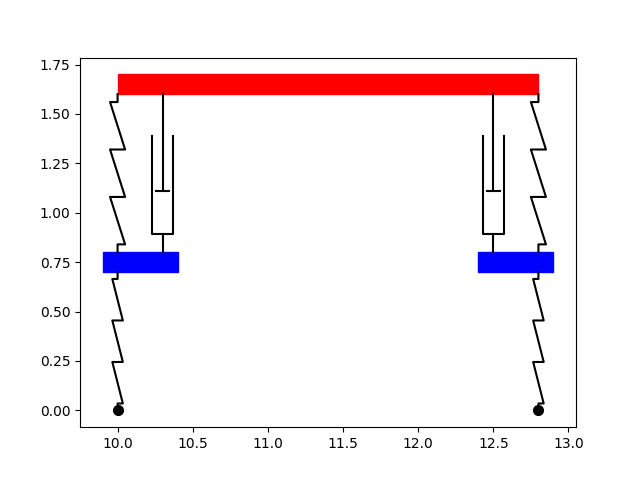

In [6]:
# Let's draw a half car!
half_car = HalfCar()

fig_half_car, axs_half_car = plt.subplots()
half_car.draw(axs=axs_half_car, x=10, y_rf=0, y_uf=0, y_rb=0, y_ub=0, y_s=0, a_f=1.4, a_b=1.4, theta=0)
plt.show()

In [7]:
grader.check("draw_half_car")

draw_half_car results: All test cases passed!

## Part 2: Simulating the half car with a state space model

It's a bit more work, and requires one new mathematical trick, but we can also distill a half car into a state space system.

First, I will describe the state space system. Then, we will put it to work to simulate the half car.

### $y_s$: the y position of the sprung mass (body)

The sprung mass has two springs and two dampers acting on it, but the force is tempered by the angle of the sprung mass ($\theta$):

$$m\ddot{y_s} = -k_{sf}(y_s - y_{uf} - a_{f}\sin{\theta}) - k_{sb}(y_s - y_{ub} + a_{b}\sin{\theta}) - c_{f}(\dot{y_s} - \dot{y_{uf}} - a_{f}\dot{\theta}\cos{\theta}) - c_b(\dot{y_s} - \dot{y_ub} + a_{b}\dot{\theta}\cos{\theta})$$

We can simplify this expression with the [small-angle approximation](https://en.wikipedia.org/wiki/Small-angle_approximation), which states that, for small angles:

$$\sin{\theta} \approx \theta$$

$$\cos{\theta} \approx 1$$

We expect that the body is pitched by only a small angle, so we will trade simulation fidelity for a simpler system by applying this substitution, giving us:

$$m_s\ddot{y_s} = -k_{sf}(y_s - y_{uf} - a_{f}\theta) - k_{sb}(y_s - y_{ub} + a_{b}\theta) - c_{f}(\dot{y_s} - \dot{y_{uf}} - a_{f}\dot{\theta}) - c_b(\dot{y_s} - \dot{y_{ub}} + a_{b}\dot{\theta})$$

Like before, we can move terms around and solve for $\ddot{y_s}$ in terms of our four state variables:

$$m_s\ddot{y_s} = -k_{sf}y_s + k_{sf}y_{uf} + k_{sf}a_{f}\theta - k_{sb}y_s + k_{sb}y_{ub} - k_{sb}a_{b}\theta - c_{f}\dot{y_s} + c_{f}\dot{y_{uf}} + c_{f}a_{f}\dot{\theta} - c_b\dot{y_s} + c_b\dot{y_{ub}} - c_{b}a_{b}\dot{\theta}$$

$$m_s\ddot{y_s} = y_s(-k_{sf}-k_{sb}) + k_{sf}y_{uf} + \theta(k_{sf}a_{f} - k_{sb}a_{b}) + k_{sb}y_{ub} + c_{f}\dot{y_{uf}} + (c_{f}a_{f} - c_ba_{b})\dot{\theta} - \dot{y_s}(c_b + c_{f}) + c_b\dot{y_{ub}}$$

$$\ddot{y_s} = \frac{-k_{sf}-k_{sb}}{m_s}y_s + \frac{k_{sf}}{m_s}y_{uf} + \frac{k_{sb}}{m_s}y_{ub} + \frac{k_{sf}a_{f} - k_{sb}a_{b}}{m_s}\theta + \frac{-c_b - c_{f}}{m_s}\dot{y_s} + \frac{c_{f}}{m_s}\dot{y_{uf}} + \frac{c_b}{m_s}\dot{y_{ub}} + \frac{c_{f}a_{f} - c_ba_{b}}{m_s}\dot{\theta}$$

### $y_{uf}$ and $y_{ub}$: y position of the front and back unsprung masses (wheels)

Both of these positions are governed by the same equations:

$$m_{uf}\ddot{y_{uf}} = k_f(y_s - y_{uf} - a_f\sin{\theta}) + c_f(\dot{y_s} - \dot{y_{uf}} - a_{f}\dot{\theta}\cos{\theta}) - k_{tf}(y_{uf} - y_{rf})$$

$$m_{ub}\ddot{y_{ub}} = k_b(y_s - y_{ub} + a_b\sin{\theta}) + c_b(\dot{y_s} - \dot{y_{ub}} + a_b\dot{\theta}\cos{\theta}) - k_{tb}(y_{ub} - y_{rb})$$

Once again, we can apply the small angle approximation to simplify:

$$m_{uf}\ddot{y_{uf}} = k_f(y_s - y_{uf} - a_f\theta) + c_f(\dot{y_s} - \dot{y_{uf}} - a_{f}\dot{\theta}) - k_{tf}(y_{uf} - y_{rf})$$

$$m_{ub}\ddot{y_{ub}} = k_b(y_s - y_{ub} + a_b\theta) + c_b(\dot{y_s} - \dot{y_{ub}} + a_b\dot{\theta}) - k_{tb}(y_{ub} - y_{rb})$$

Multiply out, and we get:

$$\ddot{y_{uf}} = \frac{k_f}{m_{uf}}y_s + \frac{-k_f-k_tf}{m_{uf}}y_{uf} + \frac{-a_fk_f}{m_{uf}}\theta + \frac{c_f}{m_{uf}}\dot{y_s} + \frac{-c_f}{m_{uf}}\dot{y_{uf}} + \frac{-a_{f}c_{f}}{m_{uf}}\dot{\theta} + \frac{k_{tf}}{m_{uf}}y_{rf}$$

$$\ddot{y_{ub}} = \frac{k_b}{m_{ub}}y_s + \frac{-k_b-k_{tb}}{m_{ub}}y_{ub} + \frac{k_{b}a_{b}}{m_{ub}}\theta + \frac{c_b}{m_{ub}}\dot{y_s} + \frac{-c_b}{m_{ub}}\dot{y_{ub}} + \frac{c_{b}a_b}{m_{ub}}\dot{\theta} + \frac{k_{tb}}{m_{ub}}y_{rb}$$

### $\theta$: angle of the sprung mass

$$I_y\ddot{\theta} = a_{f}k_{f}(y_s - y_{uf} - a_f\sin{\theta}) - a_{b}k_{b}(y_s - y_{ub} + a_{b}\sin{\theta}) + a_{f}c_{f}(\dot{y_s} - \dot{y_{uf}}-a_f\dot{\theta}\cos{\theta}) - a_{b}c_{b}(\dot{y_s} - \dot{y_{ub}} + a_b\dot{\theta}\cos{\theta})$$

Once again, small angle approximation makes this simpler:

$$I_y\ddot{\theta} = a_{f}k_{f}(y_s - y_{uf} - a_f\theta) - a_{b}k_{b}(y_s - y_{ub} + a_{b}\theta) + a_{f}c_{f}(\dot{y_s} - \dot{y_{uf}}-a_f\dot{\theta}) - a_{b}c_{b}(\dot{y_s} - \dot{y_{ub}} + a_b\dot{\theta})$$

Multiply out, and we get:

$$\ddot{\theta} = \frac{a_{f}k_{f} - a_{b}k_{b}}{I_y}y_s + \frac{-a_fk_f}{I_y}y_{uf} + \frac{a_bk_b}{I_y}y_{ub} + \frac{-a_{f}^{2}k_f - a_{b}^{2}k_b}{I_y}\theta + \frac{a_fc_f - a_bc_b}{I_y}\dot{y_s} + \frac{-a_fc_f}{I_y}\dot{y_{uf}} + \frac{a_bc_b}{I_y}\dot{y_{ub}} + \frac{a_{f}^{2}c_f - a_b^2c_b}{I_y}\dot{\theta}$$


### State space model

Like before, we can derive the state space model from the equations above.

#### $A$: The transition matrix

| | $y_s$ | $\theta$ | $y_{uf}$ | $y_{ub}$ | $\dot{y_s}$ | $\dot{\theta}$ | $\dot{y_{uf}}$ | $\dot{y_{ub}}$ |
|-|-------|----------|----------|----------|-------------|----------------|----------------|----------------|
| $\dot{y_s}$ | 0 | 0 | 0 | 0 | 1 | 0 | 0| 0|
| $\dot{\theta}$ | 0 | 0 | 0 | 0 | 0 | 1 | 0| 0|
| $\dot{y_{uf}}$ | 0 | 0 | 0 | 0 | 0 | 0 | 1| 0|
| $\dot{y_{ub}}$ | 0 | 0 | 0 | 0 | 0 | 0 | 0| 1|
| $\ddot{y_s}$ | $\frac{-k_{sf}-k_{sb}}{m_s}$ | $\frac{k_{sf}a_{f} - k_{sb}a_{b}}{m_s}$ | $\frac{k_{sf}}{m_s}$ | $\frac{k_{sb}}{m_s}$ | $\frac{-c_b - c_{f}}{m_s}$ | $\frac{c_{f}a_{f} - c_ba_{b}}{m_s}$ | $\frac{c_{f}}{m_s}$ | $\frac{c_b}{m_s}$ |
| $\ddot{\theta}$ | $\frac{a_{f}k_{f} - a_{b}k_{b}}{I_y}$ | $\frac{-a_{f}^{2}k_f - a_{b}^{2}k_b}{I_y}$ | $\frac{-a_fk_f}{I_y}$ | $\frac{a_bk_b}{I_y}$ | $\frac{a_fc_f - a_bc_b}{I_y}$ | $\frac{-a_{f}^{2}c_f - a_b^2c_b}{I_y}$ | $\frac{-a_fc_f}{I_y}$ | $\frac{a_bc_b}{I_y}$ | 
| $\ddot{y_{uf}}$ | $\frac{k_f}{m_{uf}}$ | $\frac{-a_fk_f}{m_{uf}}$ | $\frac{-k_f-k_{tf}}{m_{uf}}$ | 0 | $\frac{c_f}{m_{uf}}$ | $\frac{-a_{f}c_{f}}{m_{uf}}$ | $\frac{-c_f}{m_{uf}}$ | $0$ |
| $\ddot{y_{ub}}$ | $\frac{k_b}{m_{ub}}$ | $\frac{k_{b}a_{b}}{m_{ub}}$ | $0$ | $\frac{-k_b-k_{tb}}{m_{ub}}$ | $\frac{c_b}{m_{ub}}$ | $\frac{c_{b}a_b}{m_{ub}}$ | $0$ | $\frac{-c_b}{m_{ub}}$ |


#### $B$: The input matrix

| | $y_{rf}$ | $y_{rb}$ |
|-|-------|----------|
| $\dot{y_s}$ | 0 | 0 |
| $\dot{\theta}$ | 0 | 0 |
| $\dot{y_{uf}}$ |  0 | 0 |
| $\dot{y_{ub}}$ |  0 | 0 |
| $\ddot{y_s}$ | 0 | 0 |
| $\ddot{\theta}$ | 0 | 0 |
| $\ddot{y_{uf}}$ | $\frac{k_{tf}}{m_{uf}}$ | 0 |
| $\ddot{y_{ub}}$ | 0 | $\frac{k_{tb}}{m_{ub}}$ |

#### $C$: The output matrix

| | $y_s$ | $\theta$ | $y_{uf}$ | $y_{ub}$ | $\dot{y_s}$ | $\dot{\theta}$ | $\dot{y_{uf}}$ | $\dot{y_{ub}}$ |
|-|-------|----------|----------|----------|-------------|----------------|----------------|----------------|
| $y_s$ | 1 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| $\theta$ | 0 | 1 | 0 | 0 | 0 | 0 | 0 | 0 |
| $y_{uf}$  | 0 | 0 | 1 | 0 | 0 | 0 | 0 | 0 |
| $y_{ub}$ | 0 | 0 | 0 | 1 | 0 | 0 | 0 | 0 |

#### $D$: How input influences output

Once again, $D$ is all zeroes.

| | $y_{rf}$ | $y_{rb}$ |
|-|-------|----------|
| $\dot{y_s}$ | 0 | 0 |
| $\dot{\theta}$ | 0 | 0 |
| $\dot{y_{uf}}$  | 0 | 0 |
| $\dot{y_{ub}}$ | 0 | 0 |

### Simulating a half car with the state space system

With the state space system defined, it's time to simulate a half car. While we had you type out all of the matrices in the lab, for this homework, we will provide you with all of the matrices except for `B`.

First, the `HalfCarSimulationOutput` will contain all of the output variables we are solving for ($y_s$, $y_uf$, $y_ub$, $theta$) along with simulation parameters ($x_r$, $y_rf$, $y_rb$, `velocity`, `time`, `dt`). Define its `__init__` function.

In [8]:
class HalfCarSimulationOutput:
    """
    Helper class that contains the output of a half car simulation.
    """
    def __init__(self, velocity, time, dt, x_r, y_rf, y_rb, y_s, theta, y_uf, y_ub):
        # GUIDES: Assign the arguments to properties on `self`.
        self.velocity = velocity
        self.time = time
        self.dt = dt
        self.x_r = x_r
        self.y_rf = y_rf
        self.y_rb = y_rb
        self.y_s = y_s
        self.theta = theta
        self.y_uf = y_uf
        self.y_ub = y_ub

In [9]:
# Check code
simulation_output = HalfCarSimulationOutput(
    velocity=1,
    time=np.array([2.0]),
    dt=3,
    x_r=np.array([4.0]),
    y_rf=np.array([5.0]),
    y_rb=np.array([6.0]),
    y_s=np.array([7.0]),
    theta=np.array([8.0]),
    y_uf=np.array([9.0]),
    y_ub=np.array([10.0]))

In [10]:
grader.check("simulation_init_function")

simulation_init_function results: All test cases passed!

<!-- BEGIN QUESTION -->

Next, a `HalfCarModel` combines a `QuarterCarModel` for the front, and a `QuarterCarModel` for the back. With this setup, properties belonging to the front or back of the half car are on `self.front` and `self.back`.

For example, the mass of the back unsprung weight ($m_{ub}$) is `self.back.m_u` in the code.

We also define the mass of the `HalfCarModel`'s sprung mass to be the combined weight of the sprung mass in the front and back.

In [11]:
# GUIDES: Insert `QuarterCarModel` from Lab 7 with just its __init__ function.
# You can omit its `simulate`, `A`, `B`, `C`, and `D` functions, as we will not need them for a half car.
class QuarterCarModel:
    def __init__(self, m_s=210, m_u=53, c_s=10000, k_s=10000, k_t=200000):
        """
        Initialize the quarter car
        GUIDES: Write the function to set the properties on `self`.
        @param m_s Sprung mass in kg
        @param m_u Unsprung mass in kg
        @param c_s Damping constant in Ns/m
        @param k_s Spring constant for suspension's spring in N/m
        @param k_t Spring constant for tire in N/m
        """
        self.m_s = m_s
        self.m_u = m_u
        self.c_s = c_s
        self.k_s = k_s
        self.k_t = k_t

In [12]:
# GUIDES: Insert `interpolate_road` from Lab 7. Add two new arguments -- start_offset and stop_offset -- that default to 0.
def interpolate_road(X_r, Y_r, velocity, dt, start_offset=0, stop_offset=0):
    """
    Interpolate the road (X_r and Y_r) for a car traveling with
    the given velocity (in m/s) at timestamps every dt milliseconds.
    @param X_r numpy array containing the X coordinates of the road (in meters)
    @param Y_r numpy array containing the Y coordinates of the road (in meters)
    @param velocity of the car in m/s
    @param dt Change in time in milliseconds between interpolation points.
    @return (X, Y) of the interpolated road, as a Python tuple
    """
    # GUIDES: Define function.
    x_dt = velocity * (dt / 1000)
    X_c = np.arange(start_offset, X_r[-1] + stop_offset, x_dt)
    Y_c = np.interp(X_c, X_r, Y_r)

    return X_c, Y_c

In [13]:
class HalfCarModel:
    def __init__(self, front=QuarterCarModel(m_u=53, k_s=10000), back = QuarterCarModel(m_u=76, k_s=13000), a_f=1.4, a_b=1.47):
        self.front = front
        self.back = back
        self.a_f = a_f
        self.a_b = a_b
        self.Iy = (1/3) * self.m_s() * (self.a_f + self.a_b)**2

    # GUIDES: Write a function `m_s` that returns the sum of the front and back `m_s`.
    def m_s(self):
        return self.front.m_s + self.back.m_s

    def A(self):
        # Assigning these to a local variable makes the code below smaller.
        front = self.front
        back = self.back
        return np.array([
            [0, 0, 0, 0, 1, 0, 0, 0],
            [0, 0, 0, 0, 0, 1, 0, 0],
            [0, 0, 0, 0, 0, 0, 1, 0],
            [0, 0, 0, 0, 0, 0, 0, 1],
            [
                -(front.k_s + back.k_s)/self.m_s(),
                (front.k_s * self.a_f - back.k_s * self.a_b)/self.m_s(),
                front.k_s/self.m_s(), back.k_s/self.m_s(),
                -(back.c_s + front.c_s)/self.m_s(),
                (front.c_s*self.a_f - back.c_s * self.a_b)/self.m_s(),
                front.c_s / self.m_s(),
                back.c_s/self.m_s()
            ],
            [
                (self.a_f*front.k_s - self.a_b * back.k_s)/self.Iy,
                -(self.a_f**2 * front.k_s + self.a_b**2 * back.k_s)/self.Iy,
                -self.a_f * front.k_s/self.Iy,
                self.a_b * back.k_s / self.Iy,
                (self.a_f * front.c_s - self.a_b * back.c_s)/self.Iy,
                -((self.a_f**2 * front.c_s) + (self.a_b**2 * back.c_s))/self.Iy,
                -self.a_f * front.c_s/self.Iy,
                self.a_b * back.c_s / self.Iy
            ],
            [
                front.k_s / front.m_u,
                -self.a_f * front.k_s/front.m_u,
                -(front.k_s + front.k_t)/front.m_u,
                0,
                front.c_s/front.m_u,
                -self.a_f * front.c_s/front.m_u,
                -front.c_s/front.m_u,
                0
            ],
            [
                back.k_s/back.m_u,
                back.k_s * self.a_b / back.m_u,
                0,
                -(back.k_s + back.k_t)/back.m_u,
                back.c_s / back.m_u,
                back.c_s * self.a_b / back.m_u,
                0,
                -back.c_s/back.m_u
            ],
        ])
    
    def B(self):
        # GUIDES: Define B.
        return np.array([
            [0, 0],
            [0, 0],
            [0, 0],
            [0, 0],
            [0, 0],
            [0, 0],
            [self.front.k_t/self.front.m_u, 0],
            [0, self.back.k_t/self.back.m_u],
        ])

    def C(self):
        return np.array([
            [1, 0, 0, 0, 0, 0, 0, 0],
            [0, 1, 0, 0, 0, 0, 0, 0],
            [0, 0, 1, 0, 0, 0, 0, 0],
            [0, 0, 0, 1, 0, 0, 0, 0],
        ])

    def D(self):
        return np.zeros((4,2))

    def simulate(self, velocity, dt, x_r, y_r):
        # State space model
        sys = StateSpace(self.A(), self.B(), self.C(), self.D())

        # We need the x and y positions of both tires on the road. In the real world, the angle of the car
        # would influence the x displacement between the front and rear tire. But in our simplified model,
        # the x displacement between the tires is always the length of the car:
        #   x_rf - x_rb = a_f + a_b
        #
        # So, when traveling down our road:
        # * The rear tire will travel from first_road_position to final_road_position - self.a_f - self.a_b
        # * The front tire will travel from first_road_position + self.a_f + self.a_b to final_road_position

        # GUIDES: Use `interpolate_road` to define `x_rb`, `y_rb`, `x_rf`, and `y_rf`. Add optional arguments `start_offset` and `stop_offset`
        # that alter the start and stop of the X coordinates in the interpolation.
        # Note: x_rf will never actually be used.
        x_rb, y_rb = interpolate_road(x_r, y_r, velocity=velocity, dt=dt, start_offset=0, stop_offset=-(self.a_f + self.a_b))
        x_rf, y_rf = interpolate_road(x_r, y_r, velocity=velocity, dt=dt, start_offset=self.a_f + self.a_b, stop_offset=0)

        # Input variables are in a matrix where each column is an input variable,
        # and the `i`th row is the value of those input variables at time `time[i]`.
        y_c = np.array([
            y_rf,
            y_rb,
        ]).transpose()

        # Since x_rb begins at first_road_position, we'll use it to define time and as the x postiion of the car in the simulation output.
        time = x_rb / velocity
        [_,y_out,_] = lsim(sys, y_c, time)

        # Extract the output variables. Each column is a specific output variable
        # over time.
        y_s      = y_out[:,0]
        theta   = y_out[:,1]
        y_uf     = y_out[:,2]
        y_ub    = y_out[:,3]

        return HalfCarSimulationOutput(velocity=velocity, time=time, x_r=x_rb, dt=dt, y_s=y_s, y_uf=y_uf, y_ub=y_ub, y_rf=y_rf, y_rb = y_rb, theta=theta)

In [14]:
# GUIDES: Paste code from Lab 7 to make the road X_r, Y_r.
# Flat section, 5 meters long.
x_r_1 = [0, 5]
y_r_1 = [0, 0]

# Bump going up, 0.3 meters high
x_r_2 = [5.01, 5.5]
y_r_2 = [0, 0.3]

# Bump going down
x_r_3 = [5.51, 6.0]
y_r_3 = [0.3, 0]

# Flat section
x_r_4 = [6.01, 11]
y_r_4 = [0, 0]

X_r = np.concatenate((x_r_1, x_r_2, x_r_3, x_r_4))
Y_r = np.concatenate((y_r_1, y_r_2, y_r_3, y_r_4))

In [15]:
# GUIDES: Paste in animate_car from Lab 7, and adapt it to a half car.
# You will need to change:
# 1. FIx the call to `car.draw` so that it correctly draws both parts of the car
# 2. The calculation of `x_size_max` to account for the car's length (`a_f` + `a_b`).
# 3. `car.y_s_static` to use the value from either the front or back quarter car.
# 4. The xlim to center the camera on the center of the half car (x_r will contain the x coordinate of the rear tire).
def animate_car(car_model, car, velocity, dt, x_r, y_r, playback_speed=1.0):
    """
    Animate the given car going down the given road.
    @param car_model The `HalfCarModel` to run the simulation with.
    @param car The `HalfCar` to draw in the animation.
    @param velocity The velocity of the quarter car in the x direction in m/s.
    @param dt The time step of the simulation
    @param x_r, y_r The x and y coordinates of the road.
    @param playback_speed A value that is > 0 that indicates the playback speed (e.g., 0.1 is 10x slowdown).
    @return The animation object from animation.Funcanimation.
    """
    # GUIDES: Define function
    output = car_model.simulate(velocity=velocity, dt=dt, x_r=x_r, y_r=y_r)

    fig_anim, axs_anim = plt.subplots()

    # The x/y axes are like our camera.
    #
    # We want the y limit to be big enough to show the road, the height of the car, and some extra buffer above the car.
    # For the y limit, find the peak in the road and add twice the car's static height.
    y_lim_max = np.max(y_r) + (car.front.y_s_static*2)
    # We want the x limit to show the full length of the car plus a buffer, and change its offset depending on the
    # car's position. We accomplish this goal by setting it to 2x the car's width.
    x_size_max = car_model.a_f + car_model.a_b

    # We want the size of the x and y axs to be the same so the aspect ratio of the output isn't squished.
    fig_height = y_lim_max
    half_car = HalfCar()

    def draw_car_frame(i):
        """
        Draws frame `i` of our animation into axs_anim.
        @param i Integer indicating which frame of the animation we are on.
        """
        axs_anim.clear()
        # Set the y limit just a little below 0 so we see the road line at y=0.
        axs_anim.set_ylim([-0.1, fig_height])
        # Center the camera on the car's current x position on the road.
        axs_anim.set_xlim([output.x_r[i] - 1.5, output.x_r[i] + (x_size_max) + 1.5])
        # Draw the original road line, not output.x_r. output.x_r is sampled.
        axs_anim.plot(x_r, y_r, 'k')

        car.draw(axs=axs_anim, x=output.x_r[i], y_rf=output.y_rf[i], y_uf=output.y_uf[i], y_rb=output.y_rb[i], y_ub=output.y_ub[i], y_s=output.y_s[i], a_f=car_model.a_f, a_b=car_model.a_b, theta=output.theta[i])

    # We disable repeats for animations because the animation will repeat forever, which can cause issues when re-running a cell.
    anim = animation.FuncAnimation(fig_anim, draw_car_frame, frames=len(output.x_r), interval=output.dt / playback_speed, repeat=False)

    return anim

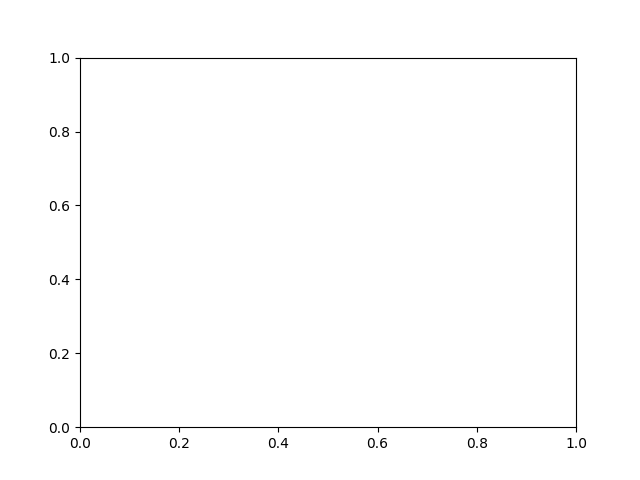

In [16]:
# Check code: Animate the half car.
half_car_model = HalfCarModel()
half_car_anim = animate_car(half_car_model, half_car, velocity=10, dt=5, x_r=X_r, y_r=Y_r)

<!-- END QUESTION -->

## Part 3: Fixing the simulation.

The simulation hardcodes the mass moment of inertia as 1100 $kg.m^2$, but that isn't correct for every car, since the length and weight of the car influences this value.

Change the simulation to approximate the mass moment of inertia of the car as a rod with an evenly distributed mass rotating about its end.


In [17]:
# 10m long stretch limo that weighs ~7000 lbs.
stretch_limo_model = HalfCarModel(front=QuarterCarModel(m_u=53, c_s=20000, k_s=200000, k_t=300000, m_s=1587), back=QuarterCarModel(m_u=76, c_s=20000, k_s=204000, k_t=300000, m_s=1587), a_f=4.0, a_b=6.0)

print(f"Iy: {stretch_limo_model.Iy}")

Iy: 105800.0


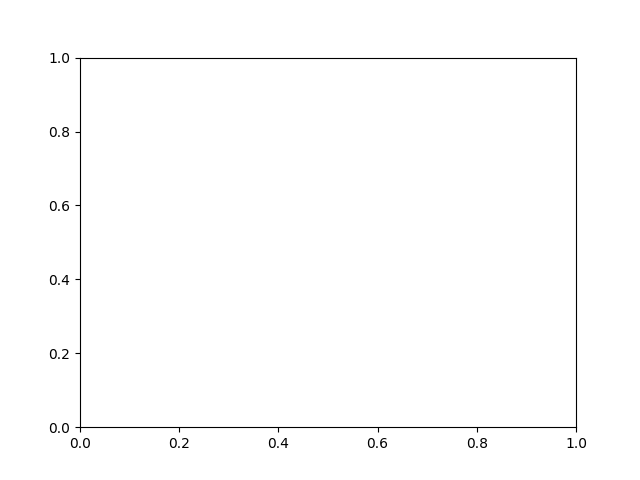

In [18]:
import copy
# Copies the model and fixes Iy to the broken value so you can compare before/after a fix.
broken_model = copy.deepcopy(stretch_limo_model)
broken_model.Iy = 1100

# Animates this super long car on a longer version of X_r with a 3.8x larger peak.
# We are using a larger dt here because the animation is slow with the large plot size.
anim = animate_car(car_model=broken_model, car=half_car, velocity=10, dt=20, x_r=X_r * 5, y_r=Y_r * 3.8)
plt.show()

c:\Users\JPizzle\GIT\JPIntroPythonProgramming\.venv\Lib\site-packages\matplotlib\animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


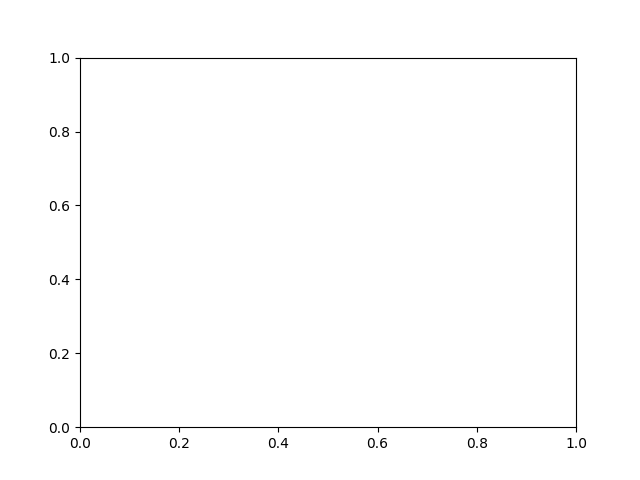

In [19]:
# animate the car with your Iy fix
anim = animate_car(car_model=stretch_limo_model, car=half_car, velocity=10, dt=20, x_r=X_r * 5, y_r=Y_r * 3.8)
plt.show()

# With the correct mass moment of inertia, the animation didn't have the same quick vibrations as when Iy was 1100,
# and it was smoother overall.

In [20]:
grader.check("half_car_simulation_fix")

half_car_simulation_fix results: All test cases passed!

<!-- BEGIN QUESTION -->

GUIDES: With the mass moment of inertia calculation fixed, how does the animation above change? Write your answer in the panel below.


<!-- END QUESTION -->

## Part 4: Visualizing vibration

Oftentimes, the goal of simulation is to affordably test a design before building the real thing. For cars, one might use a simulation to try to minimize vibrations.

We can visualize the vibration of our half cars by plotting the delta between the optimal no-vibration y position of the sprung mass in the front and the back and the actual y position on a given road.

Recall how we determine the `y` position of the sprung mass in `HalfCar`'s `draw` function. For simplicity, let's focus on the back tire:

```python
y_sb = y_s + (a_b * theta) + self.back.y_s_static
```

Or, in fancy math notation:

$$y_{sb} = y_s + (a_b * \theta) + y_{s_{static}}$$

We want to know the delta between the car with _no vibration_ and the actual car.

No vibration would be:

$$y_{static} = y_{rb} + y_{s_{static}}$$

So, the delta would be:

$$y_{sb} - y_{static} = y_s + (a_b * \theta) + y_{s_{static}} - y_{rb} + y_{s_{static}} = y_s + (a_b * \theta) - y_{rb}$$

Your task is to perform this calculation on the Numpy arrays in the simulation output and graph it. Compare the vibrations of the broken limo from part 3 and the fixed limo.

In [ ]:
# Perform the simulation to get the output.
stretch_model_output = stretch_limo_model.simulate(velocity=10, dt=4, x_r=X_r * 5, y_r=Y_r * 3.8)
broken_model_output = broken_model.simulate(velocity=10, dt=4, x_r=X_r * 5, y_r=Y_r * 3.8)

In [ ]:
# GUIDES: Write code to calculate and plot the vibration of the non-broken and broken limo. You should use two subplots -- one for each limo -- and fix the axes to be the same.
# The first plot should be the non-broken limo.
fig_vib, axs_vib = (..., ...)


In [ ]:
## Part 4, cont
# Now, go back and modify `HalfCarSimulationOutput` to contain a `sprung_mass_displacement` function to perform the calculation you did above:
#
#  def sprung_mass_displacement(self, car_model):
#    """
#    Calculates the sprung mass displacement at the back tire.
#    Used for vibration analysis.
#    """
#    ...

# **Important: After you add this method, re-run the previous code cells in this section.** Old simulation outputs created before you added this function on the class will not have this function.

# Next, write code below to make the same plots as above, but using the `sprung_mass_displacement` function.

In [ ]:
# GUIDES: Same plot as before, but use `sprung_mass_displacement`.

In [ ]:
grader.check("visualize_vibration")

<!-- BEGIN QUESTION -->

GUIDES: How does the vibration differ between the two outputs in the previous problem? Write your answer below

<!-- END QUESTION -->

## Part 5a: Cars

Now that we have a working half-car simulation, let's play with it a bit. Let's define two different half car and ride them down three different road -- two that we provide, and one that you will define. We can then plot their vibrations and compare.

The first half car will be a normal internal combustion engine, and the second will be an electric car.

For simplicity, we will be modeling the half cars with the weight of a full car.

### Internal combustion engine: 2025 Honda Civic

We will base our internal combustion engine model on a 2025 Honda Civic.

The Civic puts about 60% of its weight in the front, and 40% of its weight in the back, and its curb weight is about 1331kg ([source](https://www.dellahonda.net/how-much-does-a-honda-civic-weigh.html#:~:text=Honda%20Civic%20models%20have%20a,with%20good%20handling%20and%20balance.)).

Curb weight includes both sprung and unsprung masses. We will assume that the unsprung mass is about 90kg total, with 60% in the front, which seems in line with estimations from similar cars ([source](https://www.civicxi.com/forum/threads/2023-civic-si-spring-rates-motion-ratio-ride-frequencies-autocross.52362/)).

$$m_{curb} = m_s + m_u = 1331 - 90kg$$

$$m_u = 90kg$$

$$m_s = m_{curb} - m_u = 1331kg - 90kg = 1241kg$$

$$m_{uf} = 0.6 * m_u$$

$$m_{ub} = 0.4 * m_u$$

$$m_{sf} = 0.6 * m_s$$

$$m_{sb} = 0.4 * m_s$$


The 2025 Honda Civic is ~4.69m long. With 60% of the weight in the front, that places the center of mass closer to the front and further from the back:

$$l = 4.69m$$

$$a_f = 0.4 * l$$

$$a_b = 0.6 * l$$

For the suspension, we'll make a few educated guesses. Calculating the spring constant is:

$$k_s = \frac{4\pi^2f^2m_s}{mr^2}$$

...where $f$ is the natural frequency of the spring (in Hz), $m_s$ is the sprung mass, and $mr$ is the motion ratio of spring to wheel (how much the spring travels relative to the wheel).

The natural frequency of a passenger car is around 1Hz, and this isn't a super heavy car, so let's use $f=0.7 Hz$ for this car. And the motion ratio is frequently near 1, so let's arbitrarily decide $mr=0.8$ as the motion ratio.

That would make $k_s$:

$$k_{sf} = \frac{4\pi^2*0.7Hz^2*0.6 * 1241kg}{0.8^2} = 22506 N/m$$

$$k_{sb} = \frac{4\pi^2*0.7Hz^2*0.4 * 1241kg}{0.8^2} = 15004 N/m$$

To keep the car from vibrating excessively, we're going to add _damping_. For this we will need to set reasonable values for $c_{sf}$ and $c_{sb}$.

The damping constants are defined as:

$$c_s = 2 * m_s * dr * f * g$$

...where $f$ is the frequency of the spring _in radians_, $dr$ is the _damping ratio_, and $g$ is gravity (9.81 m/s).

The frequency of the suspension springs of the Civic is 0.7 Hz. We can convert Hz to radians by multiplying them by $2\pi$. However, we need the damping ratio.

The damping ratio of a regular car is often between 0.2 and 0.25 ([source](https://www.researchgate.net/figure/ehicle-typical-damping-coefficient_tbl1_245401813)), so we will arbitrarily use 0.25 for the Civic.

Thus, the damping constants are:

$$c_{sf} = 2 * m_{sf} * 0.25 * (0.7 Hz * 2\pi rads/Hz) * 9.81 m/s = 16063 Ns/m$$

$$c_{sb} = 2 * m_{sb} * 0.25 * (0.7 Hz * 2\pi rads/Hz) * 9.81 m/s = 10708.7 Ns/m$$


Finally, we'll use $k_{tf} = k_{tb} = 200000 N/m$, which is a reasonable baseline for a passenger car.

Now we can define the car!

In [ ]:
# GUIDES: Define the internal combustion engine car model using the values above.
combustion_car_model = ...

In [ ]:
grader.check("cars_combustion")

### Electric car: 2025 Hyundai Ioniq 6

For our electric car, we'll choose another sedan: Hyundai's Ioniq 6. As an electric vehicle, this car is considerably heavier than the Civic due to battery weight -- a 1985 kg curb weight. We'll assume 120 kg of that curb weight is unsprung weight due to the heavier tires needed to support that weight.

Unlike the Civic, the Ioniq 6 is evenly balanced, with 50% of its weight falling on the front tires, and 50% on the back tires. That's because most of the weight in an EV is from batteries, which can be broken up to balance the vehicle's weight. This also makes our calculations simpler, since the front half of the car will use the same constants as the back half of the car!

Thus:

$$m_{sf} = m_{sb} = 0.5 * (1985 kg - 120 kg)$$

$$m_{uf} = m_{ub} = 0.5 * 120 kg$$

The Ioniq 6 is 4.85m long, making:

$$a_f = a_b = 0.5 * 4.85 m$$

For suspension, we'll once again use a motion ratio of 0.8, but up the frequency of the spring to 1.0 Hz, making:

$$k_{sf} = k_{sb} = \frac{4\pi^2*1.0Hz^2*0.5 * 1865 kg}{0.8^2} = 57521 N/m$$

Once again, we are constructing these cars with no damping, so:

$$c_{sf} = c_{sb} = 0$$

Since this car is 50% heavier than the Civic, we'll increase the tire spring constant by 50%:

$$k_{tf} = k_{tb} = 300000 N/m$$

For the spring constant, we have spring with frequency 1.0 Hz, and we will arbitrarily use 0.2 as its damping ratio, making:

$$c_{sf} = c_{sb} = 2 * m_{sf} * 0.2 * (1.0 Hz * 2\pi rads/Hz) * 9.81 m/s = 22991 Ns/m$$

Now you can define this car!

In [ ]:
# GUIDES: Define the electric car model using the values above.
electric_car_model = ...

In [ ]:
grader.check("cars_electric")

## Part 5: Roads

We will provide two roads to you, and you will define a third road. Then, you will simulate driving the cars through the roads, and plot their vibrations.

In [ ]:
# Hilly road
X_r_test_1 = np.array([0, 7, 15, 20, 25, 40])
Y_r_test_1 = np.array([0, 0, 3, 2, 0, 0 ])

# Big spike
X_r_test_2 = np.array([0, 7, 12, 15, 20, 25, 40])
Y_r_test_2 = np.array([0, 0, 0, 3, 0, 0, 0 ])

# GUIDES: Define your own road! It should be at least 40 meters long.
X_r_test_3 = ...
Y_r_test_3 = ...

In [ ]:
# Check code: You can view animations of your car model here before proceeding to plot
test_anim = animate_car(car_model=electric_car_model, car=half_car, velocity=10, dt=10, x_r=X_r_test_3, y_r=Y_r_test_3)
plt.show()

In [ ]:
# GUIDES: Make a 3x1 plot showing the cars' vibrations going down each road. Each plot should be its own road,
# with two lines: one per car. Label each plot and each line.
fig_vib3, axs_vib3 = (..., ...)


In [ ]:
grader.check("cars_roads")

<!-- BEGIN QUESTION -->

## Part 6, extra credit: Designing cars with fewer vibrations

The cars we provided mimic actual cars out there, but are not perfect for reducing cabin vibration.

Can you design an even more stable car cabin for the test roads?

In [ ]:
# GUIDES: Define a car model for your car.
stable_car_model = ...


In [ ]:
# GUIDES: Graph the vibration of your car against the damped electric and combustion car models on the three test roads.

<!-- END QUESTION -->

## Hours and collaborators
Required for every assignment - fill out before you hand-in.

Listing names and websites helps you to document who you worked with and what internet help you received in the case of any plagiarism issues. You should list names of anyone (in class or not) who has substantially helped you with an assignment - or anyone you have *helped*. You do not need to list TAs.

Listing hours helps us track if the assignments are too long.

In [ ]:

# List of names (creates a set)
worked_with_names = {"not filled out"}
# List of URLS SP26 (creates a set)
websites = {"not filled out"}
# Approximate number of hours, including lab/in-class time
hours = -1.5

In [ ]:
grader.check("hours_collaborators")

### To submit

Double check your plots. 

- Submit this .ipynb file to HW 3 (classes and simulation)

Failures: None expected